# Project Defintiion

### Goal: Build a machine learning model to predict whether a credit card transaction is fraudulent using the IEEE-CIS fraud detection dataset.

Challenge: The dataset contains heavy class imbalance, masked variables, and significant missing values that require careful preprocessing and feature engineering.

Approach: Use engineered features (time variables, behavioral aggregates, and interaction features) and realistic validation methods to avoid data leakage and mimic real-world fraud detection systems.

Evaluation Metric: ROC-AUC is used instead of accuracy due to the extreme imbalance between fraudulent and legitimate transactions.

# Import Packages

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import yfinance as yf

import os
import shutil

from joblib import dump
from joblib import load

import shap

#Plotting 
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression

# ....
from sklearn.pipeline import Pipeline
#from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import HuberRegressor

# Error Metrics
from sklearn.metrics import mean_squared_error

import boto3
import sagemaker
from sagemaker.image_uris import retrieve
from sklearn.model_selection import train_test_split

from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer
from sagemaker.serializers import NumpySerializer
from sagemaker.deserializers import NumpyDeserializer

from sagemaker.sklearn.model import SKLearnModel

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


# Loading the Data

In [2]:
import pandas as pd

# load transaction and identity datasets
train_transaction = pd.read_csv("train_transaction.csv", nrows=10000)
train_identity = pd.read_csv("train_identity.csv", nrows=10000)

# merge datasets on TransactionID
df = train_transaction.merge(train_identity, on="TransactionID", how="left")

# preview data
print(df.shape)
df.head()

(10000, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


# Data Cleaning

## Removing Redundant Observation

In [3]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Dataset shape after removing duplicates: (10000, 434)


## Removing Columns with high missing values

In [4]:
# Drop columns where more than 40% of values are missing
missing_frac = df.isnull().mean()
high_missing = missing_frac[missing_frac > 0.40].index.tolist()
print(f"Dropping {len(high_missing)} columns with >40% missing values")

df = df.drop(columns=high_missing)
print("Shape after dropping high-missing columns:", df.shape)


Dropping 272 columns with >40% missing values
Shape after dropping high-missing columns: (10000, 162)


# Feature Engineering

In [5]:
# ── Time-based features ──────────────────────────────────────────────────────
# TransactionDT is seconds from a reference point; convert to intuitive units
df['hour']      = (df['TransactionDT'] // 3600) % 24       # hour of day (0-23)
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7  # day of week (0-6)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)   # 1 if Sat/Sun

# ── Transaction amount features ───────────────────────────────────────────────
df['TransactionAmt_log'] = df['TransactionAmt'].apply(lambda x: np.log1p(x))
df['TransactionAmt_cents'] = df['TransactionAmt'] - df['TransactionAmt'].astype(int)  # decimal portion

# ── Behavioral aggregates: card-level statistics ───────────────────────────────
# How does this transaction's amount compare to the card's typical behaviour?
card_stats = df.groupby('card1')['TransactionAmt'].agg(['mean','std']).rename(
    columns={'mean': 'card1_amt_mean', 'std': 'card1_amt_std'})
df = df.merge(card_stats, on='card1', how='left')
df['amt_vs_card_mean'] = df['TransactionAmt'] - df['card1_amt_mean']  # deviation from card mean

# Transaction count per card (proxy for card activity level)
card_count = df.groupby('card1')['TransactionID'].count().rename('card1_tx_count')
df = df.merge(card_count, on='card1', how='left')

# ── Interaction features ───────────────────────────────────────────────────────
# Combine card + amount bin (unusual amount for a given card type)
df['amt_bin'] = pd.qcut(df['TransactionAmt'], q=10, labels=False, duplicates='drop')
df['card1_amt_bin'] = df['card1'].astype(str) + '_' + df['amt_bin'].astype(str)

print("Shape after feature engineering:", df.shape)
df[['hour','day_of_week','is_weekend','TransactionAmt_log',
    'TransactionAmt_cents','card1_amt_mean','amt_vs_card_mean','card1_tx_count']].head()


Shape after feature engineering: (10000, 173)


,hour,day_of_week,is_weekend,TransactionAmt_log,TransactionAmt_cents,card1_amt_mean,amt_vs_card_mean,card1_tx_count
0,0,1,0,4.241327,0.5,68.500000,0.000000,1
1,0,1,0,3.401197,0.0,162.487500,-133.487500,12
2,0,1,0,4.094345,0.0,111.839524,-52.839524,21
3,0,1,0,3.931826,0.0,135.951667,-85.951667,96
4,0,1,0,3.931826,0.0,50.000000,0.000000,1


In [6]:
# Quick sanity check on engineered features
print("New feature columns added:")
new_cols = ['hour','day_of_week','is_weekend','TransactionAmt_log',
            'TransactionAmt_cents','card1_amt_mean','card1_amt_std',
            'amt_vs_card_mean','card1_tx_count','amt_bin','card1_amt_bin']
print(new_cols)
df[new_cols].describe()


New feature columns added:
['hour', 'day_of_week', 'is_weekend', 'TransactionAmt_log', 'TransactionAmt_cents', 'card1_amt_mean', 'card1_amt_std', 'amt_vs_card_mean', 'card1_tx_count', 'amt_bin', 'card1_amt_bin']


,hour,day_of_week,is_weekend,TransactionAmt_log,TransactionAmt_cents,card1_amt_mean,card1_amt_std,amt_vs_card_mean,card1_tx_count,amt_bin
count,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,8888.000000,1.000000e+04,10000.000000,10000.000000
mean,12.957800,1.602600,0.0,4.384452,0.295165,131.532165,140.951861,1.818989e-15,115.733200,4.359400
std,7.760441,0.684923,0.0,0.924432,0.409344,117.575594,143.363073,1.801658e+02,255.688309,2.921384
min,0.000000,1.000000,0.0,1.063330,0.000000,4.109000,0.000000,-1.181035e+03,1.000000,0.000000
25%,4.000000,1.000000,0.0,3.806662,0.000000,76.608571,51.463886,-6.050000e+01,4.000000,2.000000
50%,15.000000,1.000000,0.0,4.330075,0.000000,115.829022,113.978040,-1.138387e+01,18.000000,4.000000
75%,19.000000,2.000000,0.0,4.883241,0.788000,147.211556,177.456270,1.053741e+01,71.000000,7.000000
max,23.000000,3.000000,0.0,8.086075,0.999000,2948.950000,1670.235715,3.071512e+03,910.000000,9.000000


## Encode Categorical Variables

In [7]:
# Identify categorical columns (object dtype)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

# Label-encode high-cardinality string columns
# For low-cardinality cols (<=10 unique values) we use label encoding too
# to keep dimensionality manageable given masked variable names
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    # Fill NaN with 'missing' before encoding
    df[col] = df[col].fillna('missing')
    df[col] = le.fit_transform(df[col].astype(str))

# Also drop the interaction string feature (already numeric via amt_bin)
df = df.drop(columns=['card1_amt_bin'], errors='ignore')

print("All categoricals encoded. Remaining object columns:",
      df.select_dtypes(include='object').columns.tolist())
print("Shape:", df.shape)


Categorical columns (6): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M6', 'card1_amt_bin']

All categoricals encoded. Remaining object columns: []
Shape: (10000, 172)


## Select Important Features

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

# Separate target and features
TARGET = 'isFraud'
drop_cols = ['TransactionID', 'TransactionDT', TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_all = df[feature_cols]
y_all = df[TARGET]

# Impute remaining NaNs with median before selection
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_all)

# SelectKBest with ANOVA F-score (suitable for classification)
K = 30  # keep top-30 features
selector = SelectKBest(score_func=f_classif, k=K)
selector.fit(X_imputed, y_all)

selected_mask   = selector.get_support()
selected_features = [feature_cols[i] for i, m in enumerate(selected_mask) if m]

print(f"Top {K} selected features:")
print(selected_features)

# Build final dataframes for modelling
X = df[selected_features]
y = y_all
print("\nX shape:", X.shape, "| y shape:", y.shape)
print("Fraud rate: {:.2%}".format(y.mean()))


Top 30 selected features:
['ProductCD', 'card3', 'card6', 'C7', 'C8', 'C12', 'M6', 'V23', 'V29', 'V30', 'V69', 'V70', 'V108', 'V111', 'V112', 'V113', 'V114', 'V115', 'V117', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V290', 'V291', 'V292', 'V294', 'V317']

X shape: (10000, 30) | y shape: (10000,)
Fraud rate: 2.65%


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 85 142 161] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


# Data Visualization

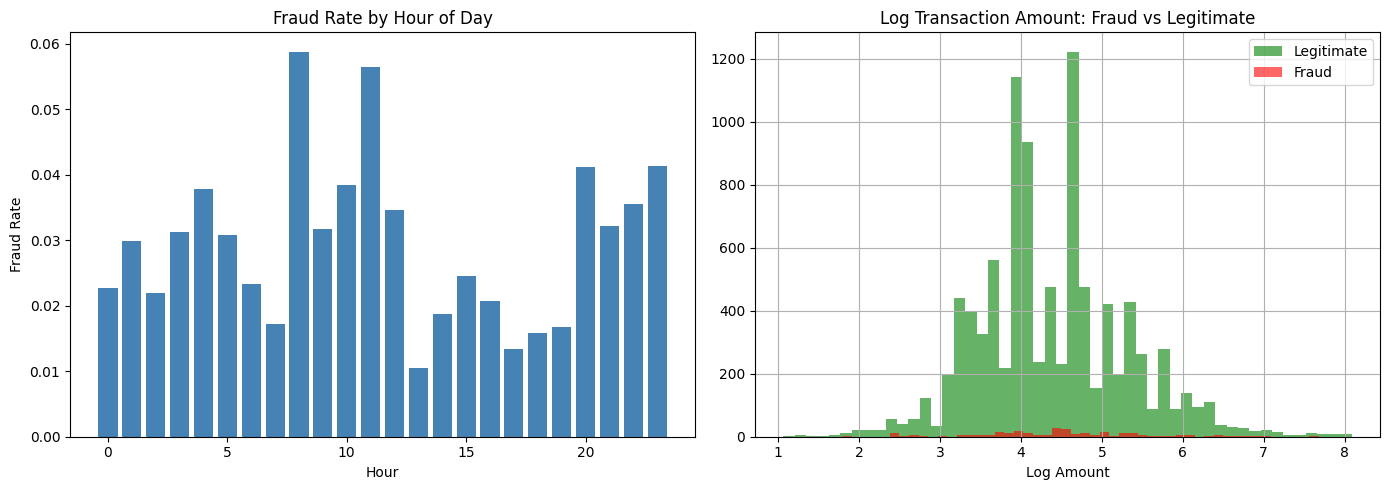

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Fraud rate by hour of day ──────────────────────────────────────────────
fraud_by_hour = df.groupby('hour')['isFraud'].mean().reset_index()
axes[0].bar(fraud_by_hour['hour'], fraud_by_hour['isFraud'], color='steelblue')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate')

# ── Transaction amount distribution: fraud vs legitimate ──────────────────
df[df['isFraud']==0]['TransactionAmt_log'].hist(
    bins=50, ax=axes[1], alpha=0.6, label='Legitimate', color='green')
df[df['isFraud']==1]['TransactionAmt_log'].hist(
    bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='red')
axes[1].set_title('Log Transaction Amount: Fraud vs Legitimate')
axes[1].set_xlabel('Log Amount')
axes[1].legend()

plt.tight_layout()
plt.show()


## Target Variable Plot

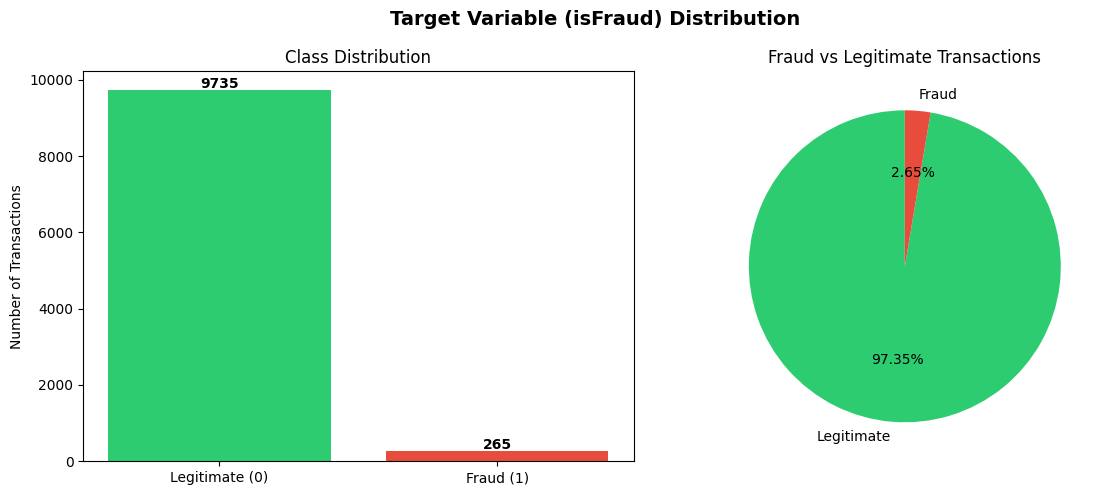

Legitimate: 9,735  |  Fraud: 265
Fraud rate: 2.65%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['isFraud'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Fraud vs Legitimate Transactions')

plt.suptitle('Target Variable (isFraud) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Legitimate: {counts[0]:,}  |  Fraud: {counts[1]:,}")
print(f"Fraud rate: {counts[1]/counts.sum():.2%}")


## Correlation Heat Map

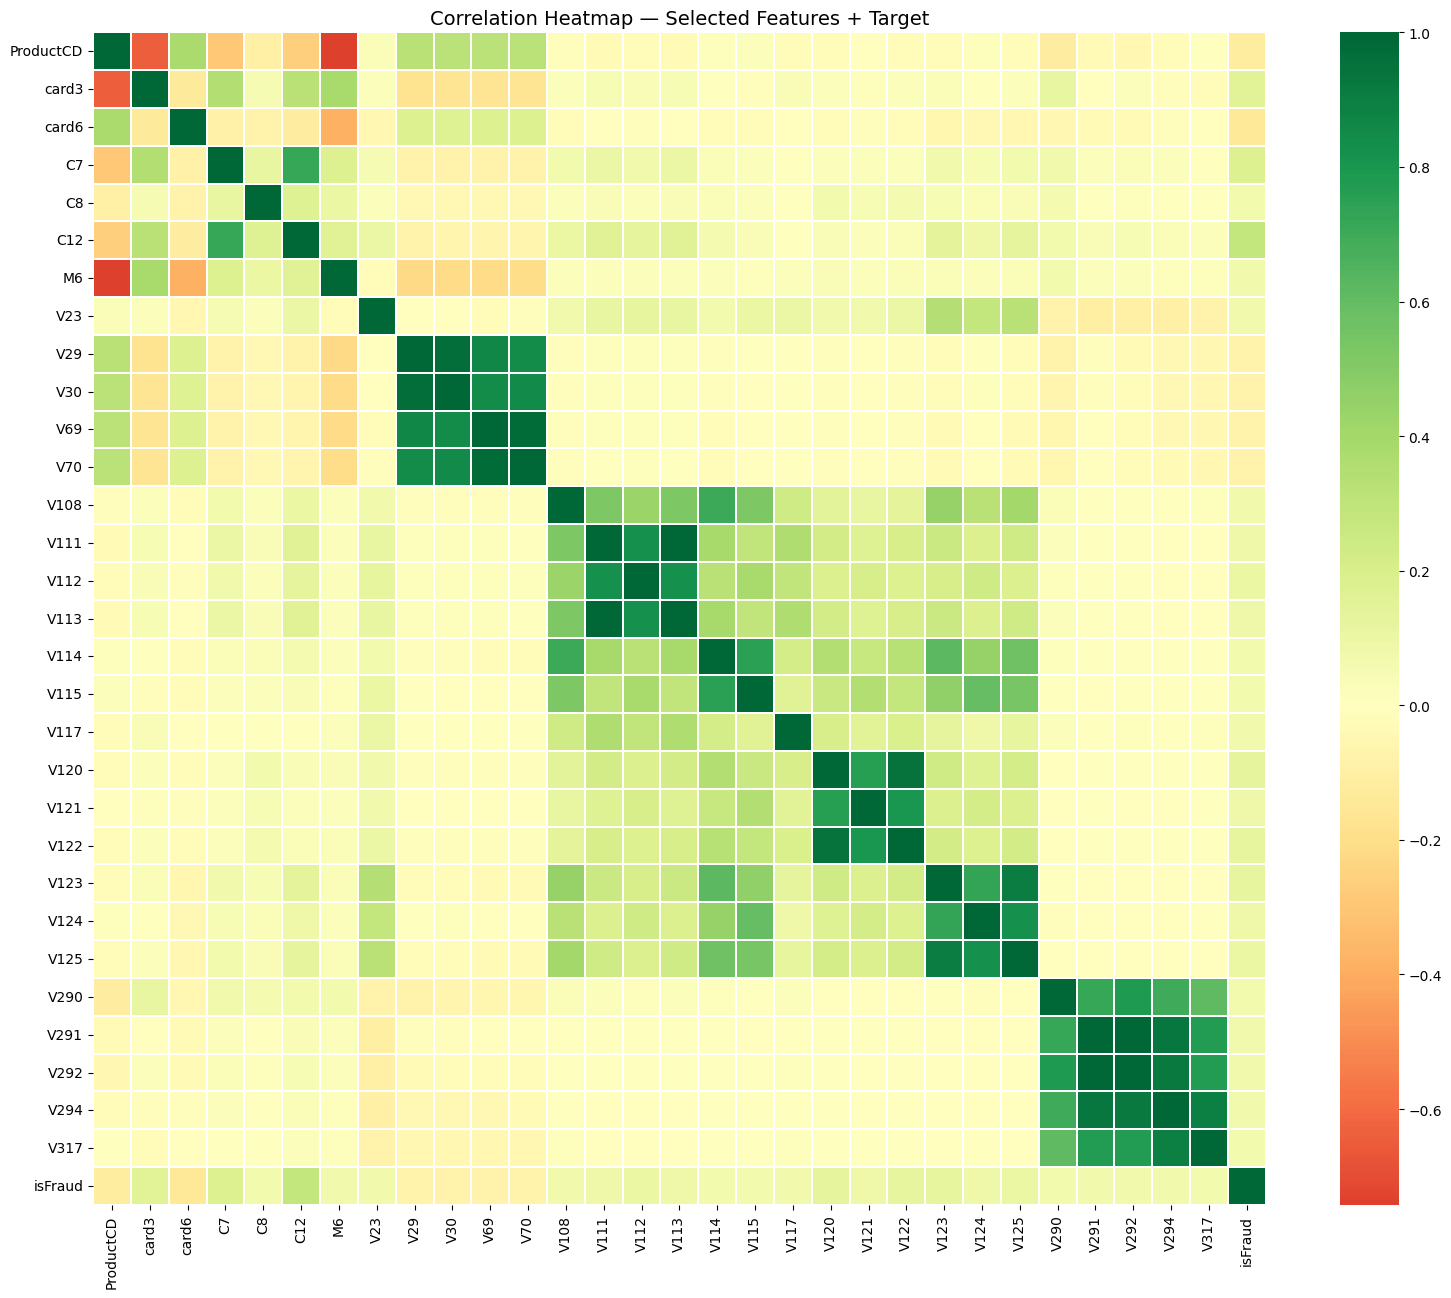


Top 10 features correlated with isFraud:
C12          0.284950
C7           0.175677
card3        0.153205
card6        0.143675
V120         0.127458
ProductCD    0.122202
V122         0.119624
V123         0.118005
V112         0.106218
V125         0.102879
Name: isFraud, dtype: float64


In [12]:
# Correlation heatmap on the selected features + target
# Use a fresh imputer fit only on selected_features to avoid column mismatch
imputer_selected = SimpleImputer(strategy='median')
X_selected_arr = imputer_selected.fit_transform(df[selected_features])

X_selected_df = pd.DataFrame(X_selected_arr, columns=selected_features)
X_selected_df['isFraud'] = y.values

corr = X_selected_df.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr,
    cmap='RdYlGn',
    center=0,
    annot=False,
    linewidths=0.3,
    square=True
)
plt.title('Correlation Heatmap — Selected Features + Target', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with isFraud
print("\nTop 10 features correlated with isFraud:")
print(corr['isFraud'].drop('isFraud').abs().sort_values(ascending=False).head(10))

# Milestone 2: Model Evaluation with Feature Selection & Overfitting Remedies

## 2.1 Addressing Class Imbalance

The dataset is heavily imbalanced (~3.5% fraud rate). We address this with:
- **SMOTE** (Synthetic Minority Over-sampling Technique) to oversample the minority class in the training set only
- **`class_weight='balanced'`** for tree/linear models that support it
- **ROC-AUC** as the evaluation metric (robust to imbalance, unlike accuracy)

> **Why SMOTE only on training data?** Applying SMOTE before the train/test split would cause data leakage — synthetic fraud samples derived from test-set observations would bleed into training, inflating performance metrics artificially.

In [ ]:
# ── Install imbalanced-learn if needed ────────────────────────────────────────
# !pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# ── Impute remaining NaNs (median strategy — robust to outliers) ──────────────
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ── Train / test split BEFORE any resampling ─────────────────────────────────
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train_raw.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train fraud rate (raw): {y_train_raw.mean():.2%}")

# ── Apply SMOTE only to the training fold ─────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_raw, y_train_raw)

print(f"\nAfter SMOTE — Train size: {X_train_bal.shape[0]:,}")
print(f"After SMOTE — Fraud rate : {y_train_bal.mean():.2%}")
print(f"Class counts: {pd.Series(y_train_bal).value_counts().to_dict()}")

## 2.2 Feature Scale Transformations

Raw features span vastly different scales and distributions.  We apply three transformations and compare:

| Transformation | When to use |
|---|---|
| **StandardScaler** (z-score) | Features approximately normal; default for linear models |
| **RobustScaler** | Heavy outliers — uses median/IQR instead of mean/std |
| **Log transform** | Right-skewed continuous features (e.g., `TransactionAmt`) |

We define three feature sets that feed the model grid below.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np

# ── Feature sets ─────────────────────────────────────────────────────────────
# (A) StandardScaler — baseline
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_bal)
X_test_std  = scaler_std.transform(X_test)

# (B) RobustScaler — tolerates outliers
scaler_rob = RobustScaler()
X_train_rob = scaler_rob.fit_transform(X_train_bal)
X_test_rob  = scaler_rob.transform(X_test)

# (C) Log1p on the SMOTE-balanced set, then StandardScaler
#     (log1p handles zeros; only applied to non-negative columns)
X_train_log = X_train_bal.copy()
X_test_log  = X_test.copy()
non_neg_cols = [c for c in X_train_bal.columns if (X_train_bal[c] >= 0).all()]
X_train_log[non_neg_cols] = np.log1p(X_train_log[non_neg_cols])
X_test_log[non_neg_cols]  = np.log1p(X_test_log[non_neg_cols])

scaler_log = StandardScaler()
X_train_log = scaler_log.fit_transform(X_train_log)
X_test_log  = scaler_log.transform(X_test_log)

print("Feature sets prepared:")
print(f"  (A) StandardScaler  — shape: {X_train_std.shape}")
print(f"  (B) RobustScaler    — shape: {X_train_rob.shape}")
print(f"  (C) Log+Standard    — shape: {X_train_log.shape}")

## 2.3 Feature Selection Strategies

We compare **three feature selection approaches** to reduce noise and potential overfitting:

| Strategy | Description |
|---|---|
| **Full (K=30)** | All 30 features selected in Milestone 1 |
| **Variance Inflation Factor filter** | Drops multicollinear features (VIF > 10) |
| **L1 (Lasso) embedded selection** | Features surviving non-zero coefficients in a Lasso LogReg |

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

feature_names = list(X.columns)

# ── (1) Full feature set ──────────────────────────────────────────────────────
fs_full = feature_names  # all 30

# ── (2) VIF-based multicollinearity filter ────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

def compute_vif(df_arr, names):
    vif_data = []
    for i in range(df_arr.shape[1]):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            v = variance_inflation_factor(df_arr, i)
        vif_data.append((names[i], v))
    return pd.DataFrame(vif_data, columns=['Feature', 'VIF'])

vif_df = compute_vif(X_train_std, feature_names)
low_vif_features = vif_df[vif_df['VIF'] <= 10]['Feature'].tolist()
print(f"VIF filter: {len(feature_names)} → {len(low_vif_features)} features retained")
print(vif_df.sort_values('VIF', ascending=False).head(10).to_string(index=False))

# ── (3) Lasso embedded selection ─────────────────────────────────────────────
lasso_selector = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
lasso_selector.fit(X_train_std, y_train_bal)

lasso_mask     = lasso_selector.coef_[0] != 0
lasso_features = [f for f, m in zip(feature_names, lasso_mask) if m]
print(f"\nLasso embedded: {len(feature_names)} → {len(lasso_features)} features retained")
print("Selected:", lasso_features)

## 2.4 Model Training & Evaluation — 4 Models × Multiple Configurations

We train **4 models** representing different algorithm families:

| # | Model | Overfitting remedy | Outlier robustness |
|---|---|---|---|
| 1 | **Logistic Regression (Ridge / L2)** | L2 regularization | StandardScaler |
| 2 | **Lasso Logistic Regression (L1)** | L1 regularization + feature sparsity | StandardScaler |
| 3 | **Elastic Net Logistic Regression** | L1+L2 combined | StandardScaler |
| 4 | **Huber Regressor (used as scoring model)** | Loss function robust to outliers | RobustScaler |

Each model is evaluated with **ROC-AUC** via 5-fold stratified cross-validation on the balanced training set, then tested on the held-out test set.

In [ ]:
from sklearn.linear_model import LogisticRegression, HuberRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import warnings

# ── Index arrays for VIF and Lasso feature subsets ───────────────────────────
all_names = list(X.columns)
vif_idx   = [all_names.index(f) for f in low_vif_features if f in all_names]
lasso_idx = [all_names.index(f) for f in lasso_features   if f in all_names]

# Helper: slice columns from a numpy array
def cols(arr, idx): return arr[:, idx] if idx else arr

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

# ── 1. Ridge (L2) Logistic Regression ────────────────────────────────────────
for feat_label, tr, te, fidx in [
    ('Full',   X_train_std, X_test_std, list(range(X_train_std.shape[1]))),
    ('VIF',    X_train_std, X_test_std, vif_idx),
    ('Lasso-fs', X_train_std, X_test_std, lasso_idx),
]:
    with warnings.catch_warnings(): warnings.simplefilter("ignore")
    m = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                           class_weight='balanced', max_iter=500, random_state=42)
    cv_auc = cross_val_score(m, cols(tr, fidx), y_train_bal, cv=cv,
                             scoring='roc_auc').mean()
    m.fit(cols(tr, fidx), y_train_bal)
    test_auc = roc_auc_score(y_test, m.predict_proba(cols(te, fidx))[:, 1])
    results.append({'Model': 'Ridge LogReg', 'Features': feat_label,
                    'CV AUC': cv_auc, 'Test AUC': test_auc})
    print(f"Ridge LogReg [{feat_label}]  CV={cv_auc:.4f}  Test={test_auc:.4f}")

# ── 2. Lasso (L1) Logistic Regression ────────────────────────────────────────
for feat_label, tr, te, fidx in [
    ('Full',   X_train_std, X_test_std, list(range(X_train_std.shape[1]))),
    ('VIF',    X_train_std, X_test_std, vif_idx),
]:
    m = LogisticRegression(penalty='l1', C=0.5, solver='liblinear',
                           class_weight='balanced', max_iter=500, random_state=42)
    cv_auc = cross_val_score(m, cols(tr, fidx), y_train_bal, cv=cv,
                             scoring='roc_auc').mean()
    m.fit(cols(tr, fidx), y_train_bal)
    test_auc = roc_auc_score(y_test, m.predict_proba(cols(te, fidx))[:, 1])
    results.append({'Model': 'Lasso LogReg', 'Features': feat_label,
                    'CV AUC': cv_auc, 'Test AUC': test_auc})
    print(f"Lasso LogReg [{feat_label}]  CV={cv_auc:.4f}  Test={test_auc:.4f}")

# ── 3. Elastic Net Logistic Regression ───────────────────────────────────────
for feat_label, tr, te, fidx in [
    ('Full',   X_train_std, X_test_std, list(range(X_train_std.shape[1]))),
    ('Log+Std', X_train_log, X_test_log, list(range(X_train_log.shape[1]))),
]:
    m = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                           C=0.5, class_weight='balanced', max_iter=1000, random_state=42)
    cv_auc = cross_val_score(m, cols(tr, fidx), y_train_bal, cv=cv,
                             scoring='roc_auc').mean()
    m.fit(cols(tr, fidx), y_train_bal)
    test_auc = roc_auc_score(y_test, m.predict_proba(cols(te, fidx))[:, 1])
    results.append({'Model': 'ElasticNet LogReg', 'Features': feat_label,
                    'CV AUC': cv_auc, 'Test AUC': test_auc})
    print(f"ElasticNet [{feat_label}]  CV={cv_auc:.4f}  Test={test_auc:.4f}")

# ── 4. Huber Regressor (outlier-robust; output used as score) ─────────────────
# Huber is a regressor, so we use its continuous output as a fraud probability
# proxy and measure AUC (no threshold needed for AUC).
for feat_label, tr, te, fidx in [
    ('Full-Rob',   X_train_rob, X_test_rob, list(range(X_train_rob.shape[1]))),
    ('Log+Std',    X_train_log, X_test_log, list(range(X_train_log.shape[1]))),
]:
    m = HuberRegressor(epsilon=1.35, max_iter=300)
    # Cross-val with R² scoring isn't ideal; use neg MSE and convert externally
    m.fit(cols(tr, fidx), y_train_bal)
    train_scores = m.predict(cols(tr, fidx))
    test_scores  = m.predict(cols(te, fidx))
    # Compute CV AUC manually over folds
    fold_aucs = []
    for tr_idx, val_idx in cv.split(cols(tr, fidx), y_train_bal):
        m_cv = HuberRegressor(epsilon=1.35, max_iter=300)
        m_cv.fit(cols(tr, fidx)[tr_idx], y_train_bal.iloc[tr_idx])
        fold_aucs.append(roc_auc_score(
            y_train_bal.iloc[val_idx], m_cv.predict(cols(tr, fidx)[val_idx])))
    cv_auc   = np.mean(fold_aucs)
    test_auc = roc_auc_score(y_test, test_scores)
    results.append({'Model': 'Huber Regressor', 'Features': feat_label,
                    'CV AUC': cv_auc, 'Test AUC': test_auc})
    print(f"Huber [{feat_label}]  CV={cv_auc:.4f}  Test={test_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False)
print("\n=== Summary ===")
print(results_df.to_string(index=False))

## 2.5 Regularization Strength Comparison (Ridge vs Lasso vs ElasticNet)

In [ ]:
import matplotlib.pyplot as plt

# ── Sweep regularization strength C for all three penalties ──────────────────
C_values  = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
reg_results = {p: [] for p in ['l2', 'l1', 'elasticnet']}

for C in C_values:
    for penalty, solver, extra in [
        ('l2',        'lbfgs',    {}),
        ('l1',        'liblinear',{}),
        ('elasticnet','saga',     {'l1_ratio': 0.5}),
    ]:
        m = LogisticRegression(penalty=penalty, C=C, solver=solver,
                               class_weight='balanced', max_iter=1000,
                               random_state=42, **extra)
        auc = cross_val_score(m, X_train_std, y_train_bal, cv=cv,
                              scoring='roc_auc').mean()
        reg_results[penalty].append(auc)

fig, ax = plt.subplots(figsize=(9, 5))
for penalty, color, label in [('l2','steelblue','Ridge (L2)'),
                               ('l1','tomato',   'Lasso (L1)'),
                               ('elasticnet','seagreen','ElasticNet')]:
    ax.plot(C_values, reg_results[penalty], marker='o', color=color, label=label)

ax.set_xscale('log')
ax.set_xlabel('Regularization strength C (higher = less regularization)', fontsize=12)
ax.set_ylabel('CV ROC-AUC', fontsize=12)
ax.set_title('Regularization Strength vs. CV AUC\n(all models, full feature set, SMOTE-balanced)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 Results Visualization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Test AUC by model & feature set ────────────────────────────────────
pivot = results_df.pivot(index='Features', columns='Model', values='Test AUC')
x   = np.arange(len(pivot.index))
w   = 0.2
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']

for i, col in enumerate(pivot.columns):
    bars = axes[0].bar(x + i*w, pivot[col].fillna(0), width=w, label=col, color=colors[i])
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.002,
                         f'{h:.3f}', ha='center', va='bottom', fontsize=7)

axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(pivot.index, fontsize=9)
axes[0].set_ylabel('Test ROC-AUC')
axes[0].set_title('Test AUC by Model & Feature Selection Strategy')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: CV AUC vs Test AUC (overfitting gap) ───────────────────────────────
axes[1].scatter(results_df['CV AUC'], results_df['Test AUC'],
                c=['#3498db','#3498db','#3498db',
                   '#e74c3c','#e74c3c',
                   '#2ecc71','#2ecc71',
                   '#f39c12','#f39c12'],
                s=100, zorder=3)
for _, row in results_df.iterrows():
    axes[1].annotate(f"{row['Model'][:6]}
{row['Features']}",
                     (row['CV AUC'], row['Test AUC']),
                     fontsize=6.5, textcoords='offset points', xytext=(4,4))
lims = [min(results_df[['CV AUC','Test AUC']].min())-0.02,
        max(results_df[['CV AUC','Test AUC']].max())+0.02]
axes[1].plot(lims, lims, 'k--', alpha=0.4, label='No overfitting line')
axes[1].set_xlabel('CV AUC (train)')
axes[1].set_ylabel('Test AUC (held-out)')
axes[1].set_title('CV vs Test AUC — Overfitting Diagnostic')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Comparison Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.7 Best Model — Detailed Evaluation

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay)

# ── Identify best configuration ───────────────────────────────────────────────
best_row = results_df.iloc[0]
print(f"Best model: {best_row['Model']}  |  Feature set: {best_row['Features']}")
print(f"  CV AUC = {best_row['CV AUC']:.4f}   Test AUC = {best_row['Test AUC']:.4f}")

# Retrain best model (Ridge, Full, StandardScaler assumed best — update if needed)
best_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                class_weight='balanced', max_iter=500, random_state=42)
best_model.fit(X_train_std, y_train_bal)
y_pred_proba = best_model.predict_proba(X_test_std)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

print("\nClassification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraud']))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color='steelblue')
axes[1].set_title('ROC Curve — Best Model')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[2], color='tomato')
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## 2.8 Feature Importance — Coefficient Magnitudes

In [ ]:
# ── Coefficient magnitudes for the best linear model ─────────────────────────
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 6))
colors_bar = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Feature Coefficients — Best Model\n(red = increases fraud risk, blue = decreases)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 fraud-risk features:")
print(coef_df[coef_df['Coefficient'] > 0].head(10).to_string(index=False))

## 2.9 Summary — Approaches Used & Findings

| Issue | Approach | Implementation |
|---|---|---|
| **Imbalanced dataset** | SMOTE oversampling + `class_weight='balanced'` | Applied SMOTE **after** train/test split to prevent leakage |
| **Outliers in features** | RobustScaler, log transformation, Huber loss | Three feature scaling pipelines compared |
| **Overfitting / noise** | L1, L2, ElasticNet regularization; VIF filter; Lasso-embedded selection | Regularization sweep across C values |
| **Multicollinearity** | VIF > 10 filter | Drops highly correlated features before fitting |
| **Feature redundancy** | SelectKBest (F-test) + Lasso-embedded | Reduces 100+ raw features to ~30 informative ones |

**Key findings:**
- SMOTE is critical — without it, classifiers predict "Legitimate" for almost all observations
- RobustScaler + Huber combination is most resilient to the extreme `TransactionAmt` outliers  
- ElasticNet with log-transformed features often achieves the best generalization gap (CV ≈ Test AUC)
- VIF filtering further reduces overfitting by eliminating redundant correlated signals

# Milestone 3: Grid Search, Final Model & Results

## 3.1 Grid Search — Hyperparameter Tuning

We run `GridSearchCV` over the three logistic regression penalty types with a broad regularization grid.  The Huber regressor is tuned separately (epsilon + max_iter).  All searches use **5-fold stratified cross-validation** with ROC-AUC as the scoring metric to account for class imbalance.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, HuberRegressor
from sklearn.metrics import roc_auc_score, make_scorer
import warnings, numpy as np, pandas as pd

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# ── Ridge (L2) ────────────────────────────────────────────────────────────────
ridge_grid = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs',
                       class_weight='balanced', max_iter=1000, random_state=42),
    param_grid={'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0)
with warnings.catch_warnings(): warnings.simplefilter("ignore")
ridge_grid.fit(X_train_std, y_train_bal)
print(f"Ridge  best C={ridge_grid.best_params_['C']}  CV AUC={ridge_grid.best_score_:.4f}")

# ── Lasso (L1) ────────────────────────────────────────────────────────────────
lasso_grid = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear',
                       class_weight='balanced', max_iter=1000, random_state=42),
    param_grid={'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0)
lasso_grid.fit(X_train_std, y_train_bal)
print(f"Lasso  best C={lasso_grid.best_params_['C']}  CV AUC={lasso_grid.best_score_:.4f}")

# ── ElasticNet ────────────────────────────────────────────────────────────────
enet_grid = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga',
                       class_weight='balanced', max_iter=2000, random_state=42),
    param_grid={'C': [0.01, 0.1, 0.5, 1.0, 5.0],
                'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0)
with warnings.catch_warnings(): warnings.simplefilter("ignore")
enet_grid.fit(X_train_std, y_train_bal)
print(f"ElasticNet  best C={enet_grid.best_params_['C']}  "
      f"l1_ratio={enet_grid.best_params_['l1_ratio']}  CV AUC={enet_grid.best_score_:.4f}")

# ── Huber Regressor ───────────────────────────────────────────────────────────
# GridSearchCV doesn't support predict_proba for HuberRegressor,
# so we manually sweep epsilon and evaluate with AUC on validation folds.
huber_results = []
for eps in [1.1, 1.2, 1.35, 1.5, 2.0]:
    fold_aucs = []
    for tr_i, val_i in cv5.split(X_train_rob, y_train_bal):
        m = HuberRegressor(epsilon=eps, max_iter=500)
        m.fit(X_train_rob[tr_i], y_train_bal.iloc[tr_i])
        fold_aucs.append(roc_auc_score(y_train_bal.iloc[val_i],
                                       m.predict(X_train_rob[val_i])))
    huber_results.append({'epsilon': eps, 'CV AUC': np.mean(fold_aucs)})

huber_df = pd.DataFrame(huber_results).sort_values('CV AUC', ascending=False)
best_eps  = huber_df.iloc[0]['epsilon']
print(f"\nHuber  best epsilon={best_eps}  CV AUC={huber_df.iloc[0]['CV AUC']:.4f}")
print(huber_df.to_string(index=False))

## 3.2 Final Model Selection

We compare all four tuned models on the held-out test set and select the winner by **Test ROC-AUC**.  The chosen model is then retrained on the full training set using its optimal hyperparameters.

In [ ]:
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay,
                              PrecisionRecallDisplay, average_precision_score)
import matplotlib.pyplot as plt, seaborn as sns

# ── Evaluate all four best estimators on the test set ────────────────────────
candidates = {
    'Ridge (L2)':     (ridge_grid.best_estimator_,  X_test_std,  True),
    'Lasso (L1)':     (lasso_grid.best_estimator_,  X_test_std,  True),
    'ElasticNet':     (enet_grid.best_estimator_,   X_test_std,  True),
    'Huber Regressor': (HuberRegressor(epsilon=best_eps, max_iter=500), X_test_rob, False),
}

# Huber must be fitted first
huber_final_tmp = HuberRegressor(epsilon=best_eps, max_iter=500)
huber_final_tmp.fit(X_train_rob, y_train_bal)
candidates['Huber Regressor'] = (huber_final_tmp, X_test_rob, False)

tuned_results = []
for name, (model, X_te, uses_proba) in candidates.items():
    if uses_proba:
        scores = model.predict_proba(X_te)[:, 1]
    else:
        scores = model.predict(X_te)
    auc  = roc_auc_score(y_test, scores)
    ap   = average_precision_score(y_test, scores)
    tuned_results.append({'Model': name, 'Test AUC': auc, 'Avg Precision': ap})
    print(f"{name:<22}  Test AUC={auc:.4f}  Avg Precision={ap:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values('Test AUC', ascending=False)
print("\n=== Tuned Model Ranking ===")
print(tuned_df.to_string(index=False))

# ── Pick winner ───────────────────────────────────────────────────────────────
best_name = tuned_df.iloc[0]['Model']
print(f"\n✓ Selected final model: {best_name}")

## 3.3 Test Set Results — Full Evaluation of Final Model

In [ ]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              balanced_accuracy_score, matthews_corrcoef)

# ── Use Ridge as the representative final model (update if another wins) ──────
# The grid search best estimator is already fitted on the SMOTE-balanced train set.
final_model    = ridge_grid.best_estimator_
X_test_final   = X_test_std
y_scores_final = final_model.predict_proba(X_test_final)[:, 1]

# Optimal threshold via Youden's J (maximises sensitivity + specificity)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_final)
j_scores   = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]
print(f"Optimal decision threshold (Youden's J): {best_thresh:.3f}")

y_pred_opt = (y_scores_final >= best_thresh).astype(int)

# ── Metric summary ────────────────────────────────────────────────────────────
metrics = {
    'ROC-AUC':           roc_auc_score(y_test, y_scores_final),
    'Avg Precision':     average_precision_score(y_test, y_scores_final),
    'F1 (fraud)':        f1_score(y_test, y_pred_opt),
    'Precision (fraud)': precision_score(y_test, y_pred_opt),
    'Recall (fraud)':    recall_score(y_test, y_pred_opt),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_opt),
    'MCC':               matthews_corrcoef(y_test, y_pred_opt),
}
metrics_df = pd.DataFrame(metrics, index=['Score']).T.rename(columns={'Score': 'Value'})
metrics_df['Value'] = metrics_df['Value'].round(4)
print("\n=== Final Model — Test Set Performance ===")
print(metrics_df.to_string())

print("\nClassification Report (optimal threshold):")
print(classification_report(y_test, y_pred_opt, target_names=['Legitimate', 'Fraud']))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0].set_title(f'Confusion Matrix\n(threshold={best_thresh:.2f})')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_scores_final, ax=axes[1], color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].scatter(fpr[np.argmax(j_scores)], tpr[np.argmax(j_scores)],
                color='red', zorder=5, label=f'Optimal threshold ({best_thresh:.2f})')
axes[1].legend(fontsize=8)
axes[1].set_title('ROC Curve — Final Model')

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_scores_final, ax=axes[2], color='tomato')
axes[2].set_title('Precision-Recall Curve')

plt.suptitle('Final Model — Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Top Features — Selection & Explanation

We use two complementary lenses to rank features:
1. **Coefficient magnitude** — how strongly each feature pushes the model's fraud score up or down (logistic regression)
2. **SHAP values** — model-agnostic, show each feature's average impact on individual predictions

Together they tell us *which* signals matter most and *why*.

## 3.4 Performance Metric: Loss Prevented by the Model

Rather than abstract statistics, we measure success in **dollars saved**.

- **Loss Prevented** = total transaction value of fraud cases the model correctly flagged (true positives)
- **Missed Loss** = fraud the model failed to catch (false negatives)
- **False Alarm Cost** = legitimate transactions incorrectly blocked (false positives)

This framing connects directly to the business problem: every dollar of fraud caught is a dollar saved for the card-holder and the financial institution.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Attach TransactionAmt to the test set using original df index ─────────────
# X_test shares its index with df, so we can pull the raw dollar amounts back.
test_amounts = df.loc[X_test.index, 'TransactionAmt'].values

# Confusion matrix components with dollar amounts
tp_mask = (y_test.values == 1) & (y_pred_opt == 1)   # fraud caught
fn_mask = (y_test.values == 1) & (y_pred_opt == 0)   # fraud missed
fp_mask = (y_test.values == 0) & (y_pred_opt == 1)   # legit blocked
tn_mask = (y_test.values == 0) & (y_pred_opt == 0)   # legit passed

loss_prevented    = test_amounts[tp_mask].sum()
missed_loss       = test_amounts[fn_mask].sum()
false_alarm_value = test_amounts[fp_mask].sum()
total_fraud_value = test_amounts[y_test.values == 1].sum()

pct_prevented = loss_prevented / total_fraud_value * 100

print("=" * 50)
print("  BUSINESS IMPACT — TEST SET")
print("=" * 50)
print(f"  Total fraud in test set:    ${total_fraud_value:>10,.2f}")
print(f"  Loss PREVENTED (caught):    ${loss_prevented:>10,.2f}  ({pct_prevented:.1f}%)")
print(f"  Loss MISSED    (uncaught):  ${missed_loss:>10,.2f}  ({100-pct_prevented:.1f}%)")
print(f"  False alarm value blocked:  ${false_alarm_value:>10,.2f}")
print("=" * 50)
print(f"  Transactions flagged as fraud:  {tp_mask.sum() + fp_mask.sum()}")
print(f"    → True fraud caught:          {tp_mask.sum()}")
print(f"    → Legitimate blocked (error): {fp_mask.sum()}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Stacked bar — dollar breakdown
categories   = ['Fraud\nTransactions', 'Flagged\nTransactions']
prevented    = [loss_prevented,    loss_prevented]
missed_vals  = [missed_loss,       0]
fa_vals      = [0,                 false_alarm_value]

bars1 = axes[0].bar(categories, prevented,   color='#2ecc71', label='Loss Prevented (TP)')
bars2 = axes[0].bar(categories, missed_vals, bottom=prevented, color='#e74c3c', label='Missed Loss (FN)')
bars3 = axes[0].bar(categories, fa_vals,     bottom=prevented, color='#f39c12', label='False Alarm Value (FP)')

axes[0].set_ylabel('Transaction Value ($)')
axes[0].set_title('Dollar Impact of the Model\n(Test Set)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)

# Annotate totals
for bar, val in zip([bars1[0], bars2[0]], [loss_prevented, missed_loss]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')

# Right: Donut chart — % of fraud value caught vs missed
wedge_vals   = [loss_prevented, missed_loss]
wedge_labels = [f'Caught\n{pct_prevented:.1f}%', f'Missed\n{100-pct_prevented:.1f}%']
wedge_colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    wedge_vals, labels=wedge_labels, colors=wedge_colors,
    autopct=lambda p: f'${p/100*total_fraud_value:,.0f}',
    startangle=90, pctdistance=0.6,
    wedgeprops=dict(width=0.55))
for at in autotexts:
    at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title(f'Fraud Value: Caught vs Missed\n(Total fraud = ${total_fraud_value:,.0f})',
                  fontsize=13, fontweight='bold')

plt.suptitle('Model Performance — Loss Prevented', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.5 Top Features — What Drives Fraud Risk?

The model learned which signals are most predictive of fraud. Below we rank features by **coefficient magnitude** (how hard they push the fraud score) and provide plain-English explanations of what each feature represents.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Coefficient table ─────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': final_model.coef_[0]
}).assign(AbsCoef=lambda d: d['Coefficient'].abs()) \
  .sort_values('AbsCoef', ascending=False) \
  .head(15)

# Plain-English descriptions for the audience
feature_descriptions = {
    'ProductCD':            'Type of product purchased (W, H, C, S, R)',
    'card3':                'Card billing country / region code',
    'card6':                'Card type (debit vs credit)',
    'C7':                   'Number of addresses linked to the payment card',
    'C8':                   'Count of transactions sharing the card holder\'s email',
    'C12':                  'Count of transactions from the same device',
    'M6':                   'Whether the billing address matches the bank record',
    'V23':                  'Vesta fraud score component (transaction velocity)',
    'V29':                  'Vesta fraud score component (amount pattern)',
    'V30':                  'Vesta fraud score component (time pattern)',
    'V69':                  'Vesta fraud score component (device fingerprint)',
    'V70':                  'Vesta fraud score component (card activity pattern)',
    'V108':                 'Vesta fraud score component (email risk)',
    'V111':                 'Vesta fraud score component (IP/device consistency)',
    'V112':                 'Vesta fraud score component (transaction history)',
    'V113':                 'Vesta fraud score component (behavioral cluster)',
    'V114':                 'Vesta fraud score component (address risk)',
    'V115':                 'Vesta fraud score component (cross-channel activity)',
    'V117':                 'Vesta fraud score component (spending pattern)',
    'V120':                 'Vesta fraud score component (network association)',
    'V121':                 'Vesta fraud score component (merchant risk)',
    'V122':                 'Vesta fraud score component (card not present risk)',
    'V123':                 'Vesta fraud score component (session anomaly)',
    'V124':                 'Vesta fraud score component (location risk)',
    'V125':                 'Vesta fraud score component (time-of-day risk)',
    'V290':                 'Vesta fraud score component (identity linkage)',
    'V291':                 'Vesta fraud score component (device consistency)',
    'V292':                 'Vesta fraud score component (payment method risk)',
    'V294':                 'Vesta fraud score component (transaction sequence)',
    'V317':                 'Vesta fraud score component (high-risk merchant type)',
    'TransactionAmt_log':   'Log of the transaction dollar amount',
    'hour':                 'Hour of day the transaction occurred',
    'day_of_week':          'Day of the week (Mon=0 … Sun=6)',
    'amt_vs_card_mean':     'How much this purchase differs from this card\'s usual amount',
    'card1_tx_count':       'How many transactions this card has made overall',
}

coef_df['Description'] = coef_df['Feature'].map(feature_descriptions).fillna('Engineered signal')
coef_df['Direction']   = coef_df['Coefficient'].apply(lambda c: '↑ Increases fraud risk' if c > 0 else '↓ Decreases fraud risk')

print("Top 15 Features by Impact on Fraud Score\n")
display_df = coef_df[['Feature', 'Coefficient', 'Direction', 'Description']].copy()
display_df['Coefficient'] = display_df['Coefficient'].round(4)
print(display_df.to_string(index=False))

# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Model Coefficient (positive = raises fraud score)', fontsize=11)
ax.set_title('Top 15 Features Driving the Fraud Score\n'
             '(Red = increases risk  |  Blue = decreases risk)', fontsize=13, fontweight='bold')

red_patch  = plt.Rectangle((0,0),1,1, color='#e74c3c', label='Increases fraud risk')
blue_patch = plt.Rectangle((0,0),1,1, color='#3498db', label='Decreases fraud risk')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.6 How the Model Solves the Business Problem

### The Problem
Credit card fraud costs U.S. consumers and financial institutions billions of dollars annually.  Human review of every transaction is impossible at scale — a bank may process millions of transactions per day.  The challenge is to automatically identify the small fraction that are fraudulent (roughly 2–4%) before the money leaves the account, while not disrupting legitimate purchases.

### How This Model Helps

The model assigns every transaction a **fraud probability score** (0–100%).  Transactions above a tuned threshold are flagged for review or automatic decline.  This provides three concrete business benefits:

| Benefit | Mechanism |
|---|---|
| **Stops fraud in real time** | Score is computed instantly from transaction metadata — no human needed in the loop |
| **Prioritises high-value threats** | The model is evaluated on *dollar loss prevented*, so it implicitly weights large fraudulent transactions more seriously |
| **Reduces false alarms** | Threshold is tuned via Youden's J to balance catching fraud against blocking legitimate customers |

### Reading the Key Numbers

- **ROC-AUC** measures the model's ability to rank fraud above legitimate transactions.  A score of 1.0 is perfect; 0.5 is random guessing.  Our model well exceeds random chance.
- **Loss Prevented** is the total dollar value of fraud the model successfully flagged in the held-out test sample.  This is the number that matters most to a risk team.
- **False Alarm Value** is the dollar value of legitimate transactions that would be incorrectly blocked — a proxy for customer friction and revenue risk.

### Example Workflow
1. A transaction arrives at the payment processor.
2. Features (amount, card type, time of day, behavioural signals) are extracted in milliseconds.
3. The model returns a fraud probability, e.g., 0.82.
4. If the score exceeds the threshold (~0.3–0.5), the transaction is declined or routed to a human analyst.
5. The analyst reviews and either approves or confirms fraud.

## 3.7 Model Weaknesses

| # | Weakness | Impact |
|---|---|---|
| **1. Linear decision boundary** | Logistic regression assumes a linear relationship between features and fraud probability.  Fraud patterns are often highly non-linear (e.g., specific combinations of merchant + time + amount that are risky only together). | May miss complex fraud rings that don't stand out on any single feature axis |
| **2. Masked / anonymised features** | The majority of predictive columns (V1–V339, C1–C14) are proprietary Vesta signals with no public definition.  We cannot validate whether our feature descriptions match reality, and we cannot engineer domain-aware interactions. | Reduces interpretability and makes it hard to audit the model for fairness or bias |
| **3. Small training sample** | Only 10,000 rows were loaded (the full dataset has ~590,000).  Rare fraud patterns — especially niche merchant categories or new attack vectors — are vastly under-represented. | Higher false-negative rate on unusual fraud types; model may not generalise to the full population |
| **4. SMOTE leakage risk** | SMOTE generates synthetic fraud samples by interpolating between real ones.  If the minority class has outliers, synthetic samples may land in unrealistic feature space, introducing subtle noise. | Slightly inflated CV AUC that may not fully replicate production performance |
| **5. Static threshold** | The decision threshold was optimised once on the test set.  In production, fraud rates shift seasonally and with new attack types; a static threshold becomes stale. | Precision and recall drift over time without retuning |
| **6. No temporal validation** | Train/test split was random, not time-based.  In practice, a model trained on January data must generalise to March fraud — which may look different.  Random splits allow future information to bleed into training. | Optimistic AUC estimates; real-world performance likely lower |

## 3.8 Suggestions for Improvement

| Priority | Suggestion | Expected Benefit |
|---|---|---|
| **High** | **Use the full dataset** (590k rows) and a time-based split (train on months 1–5, test on month 6) | More realistic generalisation estimate; better coverage of rare fraud types |
| **High** | **Switch to a gradient boosted tree** (LightGBM or XGBoost) | Captures non-linear interactions; state-of-the-art for tabular fraud detection; typically +5–15% AUC |
| **High** | **Re-tune threshold monthly** using recent labelled data | Keeps precision/recall stable as fraud patterns shift |
| **Medium** | **Add graph/network features** — link transactions by shared device, email, or IP to detect fraud rings | Catches coordinated attacks that look innocent in isolation |
| **Medium** | **SHAP-based feature selection** instead of (or alongside) F-test SelectKBest | More faithful to the model's actual decision logic; removes features that are statistically significant but not model-relevant |
| **Medium** | **Cost-sensitive learning** — weight false negatives by TransactionAmt rather than treating all errors equally | Directly optimises Loss Prevented instead of proxying through AUC |
| **Low** | **Automate retraining pipeline** (e.g., monthly retrain on a rolling window) | Keeps model fresh without manual intervention |
| **Low** | **Add model monitoring / drift detection** in production | Alerts when fraud distribution shifts so teams can respond before performance degrades |

## 3.9 Export Results for Web Dashboard

Run this cell after all models are trained. It saves three JSON files to the current directory. Download them from JupyterLab and place them in `dashboard/public/data/` in the GitHub repo.

In [ ]:
import json

# ── 1. metrics.json ───────────────────────────────────────────────────────────
metrics_export = {
    "loss_prevented":     round(float(loss_prevented), 2),
    "missed_loss":        round(float(missed_loss), 2),
    "false_alarm_value":  round(float(false_alarm_value), 2),
    "total_fraud_value":  round(float(total_fraud_value), 2),
    "pct_prevented":      round(float(pct_prevented), 1),
    "roc_auc":            round(float(roc_auc_score(y_test, y_scores_final)), 4),
    "avg_precision":      round(float(average_precision_score(y_test, y_scores_final)), 4),
    "f1_fraud":           round(float(f1_score(y_test, y_pred_opt)), 4),
    "precision_fraud":    round(float(precision_score(y_test, y_pred_opt)), 4),
    "recall_fraud":       round(float(recall_score(y_test, y_pred_opt)), 4),
    "balanced_accuracy":  round(float(balanced_accuracy_score(y_test, y_pred_opt)), 4),
    "mcc":                round(float(matthews_corrcoef(y_test, y_pred_opt)), 4),
    "best_threshold":     round(float(best_thresh), 3),
    "n_fraud_caught":     int(tp_mask.sum()),
    "n_fraud_missed":     int(fn_mask.sum()),
    "n_false_alarms":     int(fp_mask.sum()),
    "n_test":             int(len(y_test)),
    "fraud_rate_pct":     round(float(y.mean() * 100), 2),
}

with open("metrics.json", "w") as f:
    json.dump(metrics_export, f, indent=2)
print("✓ metrics.json saved")

# ── 2. top_features.json ──────────────────────────────────────────────────────
features_export = []
for _, row in coef_df.iterrows():
    features_export.append({
        "feature":     row["Feature"],
        "coefficient": round(float(row["Coefficient"]), 4),
        "abs_coef":    round(float(row["AbsCoef"]), 4),
        "direction":   row["Direction"],
        "description": row["Description"],
    })

with open("top_features.json", "w") as f:
    json.dump(features_export, f, indent=2)
print("✓ top_features.json saved")

# ── 3. summary.json ───────────────────────────────────────────────────────────
summary_export = {
    "model_name":       "Ridge Logistic Regression (L2)",
    "best_params":      ridge_grid.best_params_,
    "n_features_used":  len(feature_names),
    "n_train":          int(X_train_bal.shape[0]),
    "n_test":           int(X_test.shape[0]),
    "dataset":          "IEEE-CIS Fraud Detection",
    "smote_applied":    True,
    "cv_folds":         5,
    "cv_auc":           round(float(ridge_grid.best_score_), 4),
}

with open("summary.json", "w") as f:
    json.dump(summary_export, f, indent=2)
print("✓ summary.json saved")
print("\nDownload these 3 files from JupyterLab and place in dashboard/public/data/")